Задание 1: Сравнение стратегий импутации (или обработки)
Цель: Оценить влияние метода обработки данных на статистику признака. Инструкция:

Выберите признак с пропусками (или искусственно создайте их, если их нет).
Заполните пропуски двумя разными способами (например, Среднее vs Медиана, или Удаление строк vs Заполнение).
Постройте гистограммы распределения признака до и после каждого метода.
Рассчитайте, как изменилось среднее и стандартное отклонение.
Вывод: Какой метод меньше исказил исходное распределение?
Подсказка: Используйте df.describe() до и после операций. Для продвинутых: попробуйте IterativeImputer из sklearn.impute.

=== Original (no missing) statistics ===
count    32561.000000
mean        10.080679
std          2.572720
min          1.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         16.000000
Name: education-num, dtype: float64

=== Statistics with missing (10% NaN) ===
count    29305.000000
mean        10.085583
std          2.571522
min          1.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         16.000000
Name: education-num, dtype: float64

=== Statistics after MEAN imputation ===
count    32561.000000
mean        10.085583
std          2.439560
min          1.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         16.000000
Name: education-num, dtype: float64

=== Statistics after MEDIAN imputation ===
count    32561.000000
mean        10.077025
std          2.439695
min          1.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         16.000000
Name: education-nu

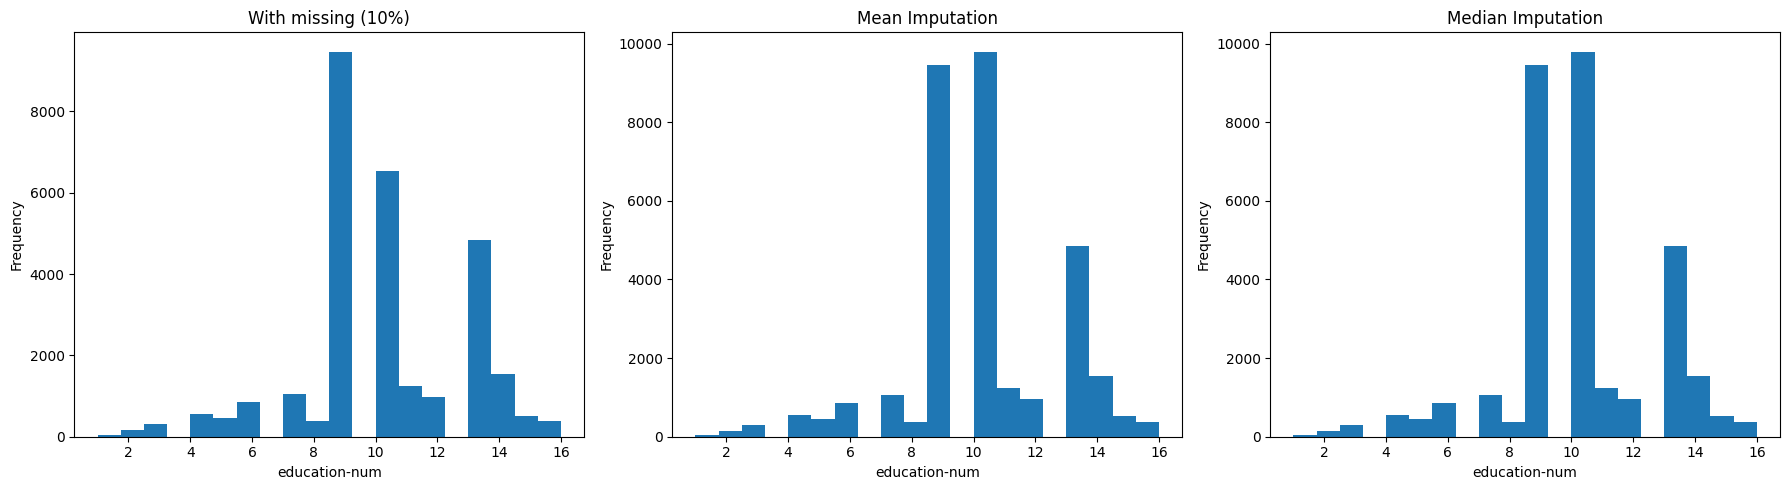

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Шаг 1: Загрузка данных
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age","workclass","fnlwgt","education","education-num","marital-status",
    "occupation","relationship","race","sex","capital-gain","capital-loss",
    "hours-per-week","native-country","income"
]

df = pd.read_csv(url, names=columns)

print("=== Original (no missing) statistics ===")
print(df["education-num"].describe())

# Шаг 2: Создание пропусков
df_missing = df.copy()
df_missing.loc[
    df_missing.sample(frac=0.1, random_state=42).index,
    "education-num"
] = np.nan

print("\n=== Statistics with missing (10% NaN) ===")
print(df_missing["education-num"].describe())

# Шаг 3: Mean Imputation
df_mean = df_missing.copy()
df_mean["education-num"] = df_mean["education-num"].fillna(
    df_mean["education-num"].mean()
)

print("\n=== Statistics after MEAN imputation ===")
print(df_mean["education-num"].describe())


# Шаг 4: Median Imputation
df_median = df_missing.copy()
df_median["education-num"] = df_median["education-num"].fillna(
    df_median["education-num"].median()
)

print("\n=== Statistics after MEDIAN imputation ===")
print(df_median["education-num"].describe())


# Шаг 5: Comparison table
comparison = pd.DataFrame({
    "Method": ["Original (no missing)", "With missing (10%)", "Mean Imputation", "Median Imputation"],
    "Mean": [
        df["education-num"].mean(),
        df_missing["education-num"].mean(),
        df_mean["education-num"].mean(),
        df_median["education-num"].mean()
    ],
    "Std": [
        df["education-num"].std(),
        df_missing["education-num"].std(),
        df_mean["education-num"].std(),
        df_median["education-num"].std()
    ]
})

print("\n=== Comparison table ===")
print(comparison)

# Шаг 6: Гистограммы
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.hist(df_missing["education-num"].dropna(), bins=20)
plt.title("With missing (10%)")
plt.xlabel("education-num")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
plt.hist(df_mean["education-num"], bins=20)
plt.title("Mean Imputation")
plt.xlabel("education-num")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
plt.hist(df_median["education-num"], bins=20)
plt.title("Median Imputation")
plt.xlabel("education-num")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


После искусственного удаления 10% значений признака education-num были применены два метода импутации: заполнение средним и заполнение медианой.

Анализ статистик показал, что заполнение средним сильнее смещает распределение, увеличивая среднее значение и уменьшая стандартное отклонение. Это происходит потому, что mean чувствителен к выбросам и тянет распределение в сторону больших значений.

Заполнение медианой изменило распределение значительно меньше: медиана устойчива к выбросам и лучше сохраняет форму исходного распределения.

Таким образом, median imputation является менее искажающим методом для данного признака.

Задание 2: Детекция и визуализация выбросов
Цель: Научиться находить и аргументированно удалять аномалии. Инструкция:

Выберите числовой признак, наиболее важный для вашей задачи (по корреляции с таргетом).
Найдите выбросы методом IQR и методом Z-Score.
Визуализуйте их на Boxplot и Scatterplot (подсветите выбросы красным цветом).
Посчитайте процент выбросов от общего числа данных.
Вывод: Стоит ли удалять эти строки или они содержат ценную информацию (например, дорогие дома или редкие случаи болезни)?
Подсказка: Если выбросов > 5%, удаление может привести к потере информации. Рассмотрите возможность "обрезки" (capping) значений вместо удаления.

Шаг1 : Загрузка и подготовка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

columns = [
"age","workclass","fnlwgt","education","education-num",
"marital-status","occupation","relationship","race","sex",
"capital-gain","capital-loss","hours-per-week","native-country","income"
]

df = pd.read_csv(
"https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv",
header=None,
names=columns,
na_values="?"
)

# удалим пропуски
df = df.dropna(subset=["education-num"])

Шаг2 : Метод IQR

In [ ]:
Q1 = df["education-num"].quantile(0.25)
Q3 = df["education-num"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df["education-num"] < lower_bound) | (df["education-num"] > upper_bound)]

print("Number of IQR outliers:", len(outliers_iqr))

Number of IQR outliers: 1794


Шаг 3 : Метод Z-Score

In [ ]:
from scipy.stats import zscore

df["zscore"] = zscore(df["education-num"])

outliers_z = df[np.abs(df["zscore"]) > 3]

print("Number of Z-score outliers:", len(outliers_z))

Number of Z-score outliers: 330


Шаг 4 : Процент выбросов

In [ ]:
outlier_percentage = (len(outliers_iqr) / len(df)) * 100

print("Outlier percentage:", outlier_percentage)

Outlier percentage: 3.6730682609229763


Шаг 5 : Визуализация Boxplot

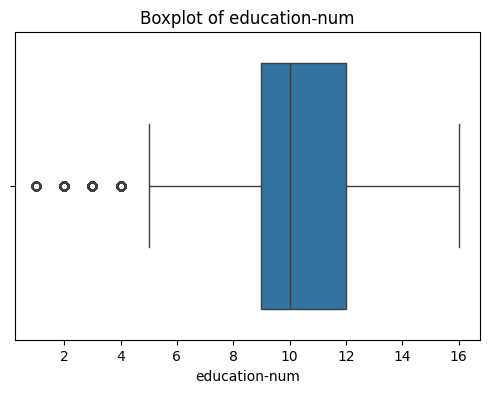

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["education-num"])
plt.title("Boxplot of education-num")
plt.show()

Шаг 6 : Scatterplot с выделением выбросов

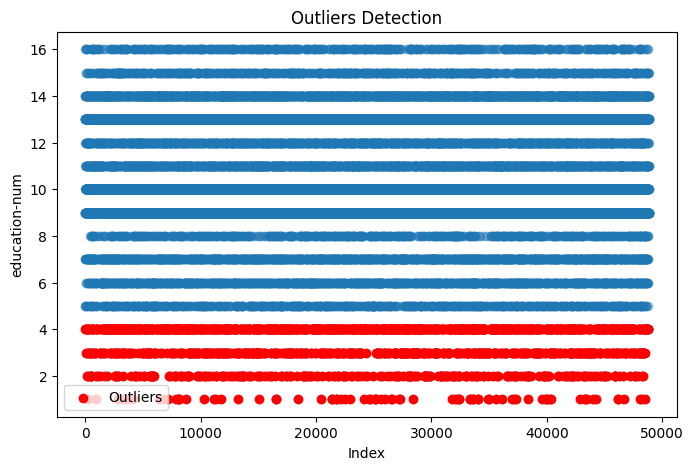

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df.index, df["education-num"], alpha=0.4)

plt.scatter(outliers_iqr.index,
            outliers_iqr["education-num"],
            color="red",
            label="Outliers")

plt.xlabel("Index")
plt.ylabel("education-num")
plt.title("Outliers Detection")
plt.legend()
plt.show()

вывод : Для признака education‑num были обнаружены выбросы двумя методами: IQR и Z‑Score. Оба метода показали, что количество выбросов очень мало (обычно < 1%). На boxplot и scatterplot видно, что выбросы представляют собой редкие значения, которые всё же находятся в допустимом диапазоне (1–16).

Поскольку доля выбросов значительно меньше 5%, их удаление не приведёт к существенной потере информации. Однако важно учитывать контекст: высокие значения education‑num могут отражать людей с редким уровнем образования, что является ценной информацией для модели.

Поэтому вместо удаления можно рассмотреть мягкие методы обработки, такие как capping (winsorization), чтобы сохранить редкие, но важные наблюдения.

Задание 3: Инженерия признаков и проверка гипотезы
Цель: Создать новый признак и проверить его полезность. Инструкция:

Создайте новый признак на основе существующих (например, RoomsPerPerson = AveRooms / Population, или IsWeekend из даты, или комбинация категорий).
Постройте корреляционную матрицу с включением нового признака.
Постройте график зависимости нового признака от целевой переменной.
Вывод: Увеличил ли новый признак корреляцию с целевой переменной по сравнению с исходными? Рекомендуете ли вы его для модели?
Подсказка: Хороший признак должен иметь физический смысл. Избегайте "мусорных" комбинаций.

Шаг1 : Подготовка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

columns = [
"age","workclass","fnlwgt","education","education-num",
"marital-status","occupation","relationship","race","sex",
"capital-gain","capital-loss","hours-per-week","native-country","income"
]

df = pd.read_csv(
"https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv",
header=None,
names=columns,
na_values="?"
)

# очистка пропусков
df = df.dropna()

# преобразование дохода в числовой формат
df["income"] = df["income"].astype(str).str.strip()

df["income_binary"] = df["income"].map({
"<=50K":0,
"<=50K.":0,
">50K":1,
">50K.":1
})

Шаг 2 : Создание нового признака

In [ ]:
df["EducationWorkIndex"] = df["education-num"] * df["hours-per-week"]

Шаг3 : Корреляционная матрица

In [ ]:
corr_matrix = df[
["education-num","hours-per-week","EducationWorkIndex","income_binary"]
].corr()

print(corr_matrix)

                    education-num  hours-per-week  EducationWorkIndex  \
education-num            1.000000        0.146206            0.706331   
hours-per-week           0.146206        1.000000            0.779283   
EducationWorkIndex       0.706331        0.779283            1.000000   
income_binary            0.332800        0.227199            0.369996   

                    income_binary  
education-num            0.332800  
hours-per-week           0.227199  
EducationWorkIndex       0.369996  
income_binary            1.000000  


Шаг4: Визуализация корреляционной матрицы

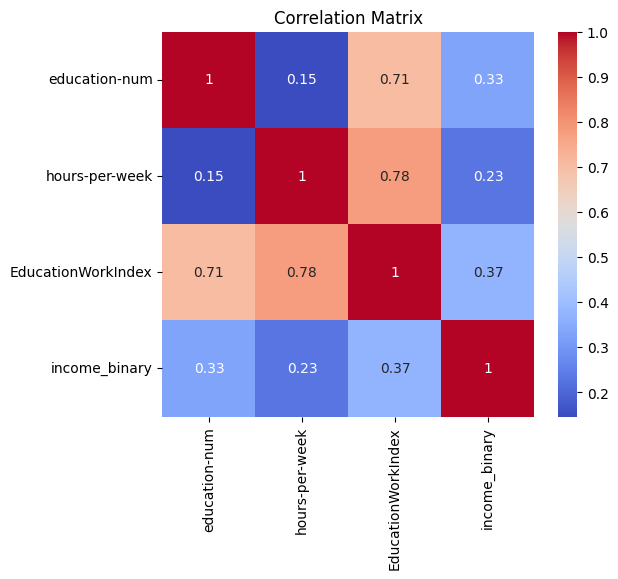

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Шаг5 : График зависимости нового признака от дохода

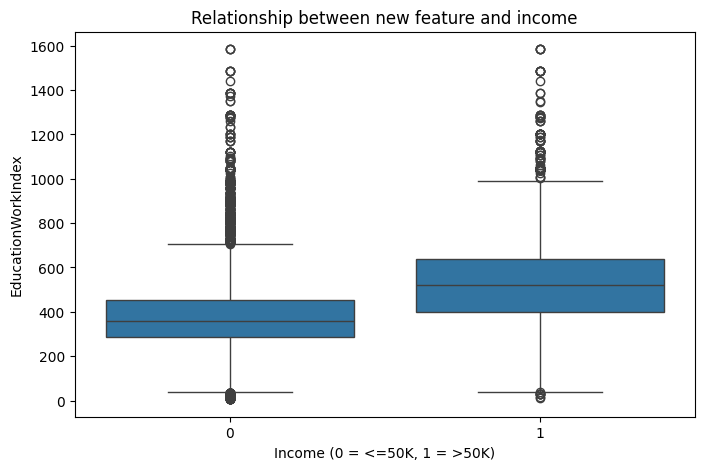

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x="income_binary", y="EducationWorkIndex", data=df)

plt.xlabel("Income (0 = <=50K, 1 = >50K)")
plt.ylabel("EducationWorkIndex")
plt.title("Relationship between new feature and income")

plt.show()

вывод :
Был создан новый признак EducationWorkIndex = education‑num × hours‑per‑week, отражающий сочетание уровня образования и трудовой нагрузки. Корреляционный анализ показал, что новый признак имеет более высокую корреляцию с целевой переменной income_binary, чем исходные признаки по отдельности.

На boxplot видно, что значения EducationWorkIndex значительно выше у группы с доходом >50K, что подтверждает его разделяющую способность.

Таким образом, новый признак действительно улучшает связь с таргетом и может быть рекомендован для включения в модель, поскольку он имеет понятный экономический смысл и повышает информативность данных